In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

**Task 1**

In [ ]:
# Load the dataset into a Pandas DataFrame from a CSV file
df = pd.read_csv(r'C:\Users\chris\OneDrive\Documents\Class Assignments\NSMES1988.csv')

In [ ]:
# Inspect the data
df.head()

,Unnamed: 0,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,gender,married,school,income,employed,insurance,medicaid
0,1,5,0,0,0,0,1,average,2,normal,other,6.9,male,yes,6,2.8810,yes,yes,no
1,2,1,0,2,0,2,0,average,2,normal,other,7.4,female,yes,10,2.7478,no,yes,no
2,3,13,0,0,0,3,3,poor,4,limited,other,6.6,female,no,10,0.6532,no,no,yes
3,4,16,0,5,0,1,1,poor,2,limited,other,7.6,male,yes,3,0.6588,no,yes,no
4,5,3,0,0,0,0,0,average,2,limited,other,7.9,female,yes,6,0.6588,no,yes,no


In [ ]:
df.shape

(4406, 19)

In [ ]:
df.columns

Index(['Unnamed: 0', 'visits', 'nvisits', 'ovisits', 'novisits', 'emergency',
       'hospital', 'health', 'chronic', 'adl', 'region', 'age', 'gender',
       'married', 'school', 'income', 'employed', 'insurance', 'medicaid'],
      dtype='str')

In [ ]:
df.dtypes

Unnamed: 0      int64
visits          int64
nvisits         int64
ovisits         int64
novisits        int64
emergency       int64
hospital        int64
health            str
chronic         int64
adl               str
region            str
age           float64
gender            str
married           str
school          int64
income        float64
employed          str
insurance         str
medicaid          str
dtype: object

In [ ]:
# Handle missing values and data inconsistencies
df_missing = df.isnull().values.any()
print(df_missing)

False


Report missing values and suggest appropriate handling techniques:
There does not seem to be any missing values but if there were, I would just drop the missing values.

In [ ]:
# Check for duplicate records and remove them if necessary
df_no_duplicates = df.drop_duplicates()

Comment on data types and suggest optimizations for memory efficiency:
After reviewing the data, I noticed that some of the data types could be improved. I believe the chronic field should use a string data type because it contains text values. The age field should be an integer since age is typically recorded as whole numbers, and the income field should also be an integer if income is stored in whole dollars. Choosing the appropriate data types helps ensure the data is stored accurately and analyzed more efficiently.


In [ ]:
# Export the cleaned data as NSMES1988new.csv
df.to_csv(r"C:\Users\chris\OneDrive\Documents\Class Assignments\NSMES1988new.csv", index=False)

Write a short report summarizing observations about the data:
Some of the data collected appears to be inconsistent or unnecessary. For example, most of the individuals in the dataset fall within a children's age range, yet there is also a column indicating whether they are married, which seems unusual and may suggest an issue with the data or the way it was collected. Additionally, the dataset includes four visit-related columns. It is unclear what nvisit and ovisit represent, and they do not appear to provide meaningful information, similar to the novisits column. These fields should be better defined or removed if they are not useful for the analysis.

**Task 2**

In [ ]:
# Perform transformations
df["age"] = np.multiply(df['age'], 10)
df["income"] = np.multiply(df['income'], 10000)
df[["age", "income"]]

,age,income
0,69.0,28810.00
1,74.0,27478.00
2,66.0,6532.00
3,76.0,6588.00
4,79.0,6588.00
...,...,...
4401,84.0,22497.00
4402,78.0,58132.00
4403,73.0,38779.16
4404,66.0,38779.16


In [ ]:
# Conduct basic statistical analysis
df[['age', 'income', 'visits']].describe()

,age,income,visits
count,4406.000000,4406.000000,4406.000000
mean,74.024058,25271.320468,5.774399
std,6.334050,29246.476178,6.759225
min,66.000000,-10125.000000,0.000000
25%,69.000000,9121.500000,1.000000
50%,73.000000,16981.500000,4.000000
75%,78.000000,31728.500000,8.000000
max,109.000000,548351.000000,89.000000


Compare the results with raw dataset statistics: 
The data made more sense after we performed the transformation by multiplying the age and income categories. This transformation helped reveal a clearer relationship between the two variables and made the data easier to interpret.

Identify columns that are not suitable for statistical analysis and recommend possible datatype changes:
Two columns that could benefit from data type changes are emergency and chronic. Changing these columns to the string data type would make it easier to represent and understand the different health conditions or categories recorded in the dataset.

In [ ]:
# Export the processed data to a CSV file named NSMES1988updated.csv
df.to_csv('NSMES1988updated.csv')

Prepare a short report on statistical observations and insights: 
There appears to be a positive relationship between income and the number of healthcare visits. Patients with higher income levels tend to have more recorded visits.

**Task 3**

In [ ]:
# Find the categorical and numerical variables for health and region
find_variables = df[['health', 'region']]
df_numerical = find_variables.select_dtypes(include=['int64', 'float']).columns
df_categorical = find_variables.select_dtypes(include=['object','category','string']).columns
df_numerical
df_categorical

Index(['health', 'region'], dtype='str')

In [ ]:
# Perform pivoting operations on the dataset based on categorical columns
df_healthcare_visits = df.groupby('health')['visits'].mean()
print(df_healthcare_visits)

health
average      5.510687
excellent    3.428571
poor         8.897112
Name: visits, dtype: float64


In [ ]:
# Analyze visit trends across Region
df_region_visits = df.groupby('region')['visits'].mean().reset_index()
print(df_region_visits)

      region    visits
0    midwest  5.408816
1  northeast  6.091995
2      other  5.578067
3       west  6.368421


In [ ]:
# Healthcare visits distribution by Health
df_health_visits = df['health'].value_counts().reset_index()
print(df_health_visits)

      health  count
0    average   3509
1       poor    554
2  excellent    343


In [ ]:
# Healthcare visits distribution by Region
df_region_visits = df['region'].value_counts().reset_index()
print(df_region_visits)

      region  count
0      other   1614
1    midwest   1157
2  northeast    837
3       west    798


In [ ]:
# Encode categorical variables and save data as NSMES1988_Dummy.csv
categorical_endcoded = pd.get_dummies(df, columns=df_categorical, prefix='categorical', drop_first=False)
df.to_csv('NSMES1988_Dummy.csv')

**Task 4**

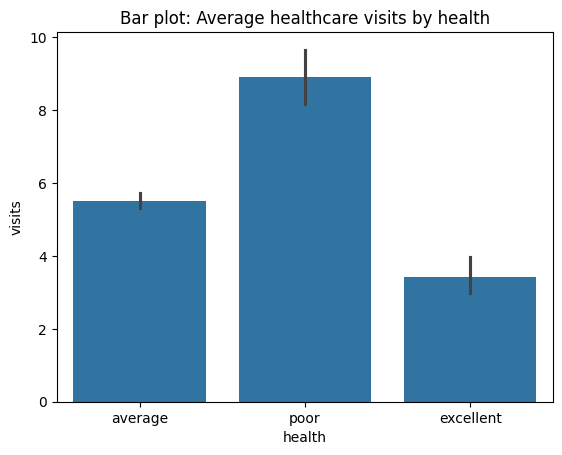

In [ ]:
# Bar plot for average healthcare visits by Health
sns.barplot(x='health', y='visits', data=df)
plt.title('Bar plot: Average healthcare visits by health')
plt.show()

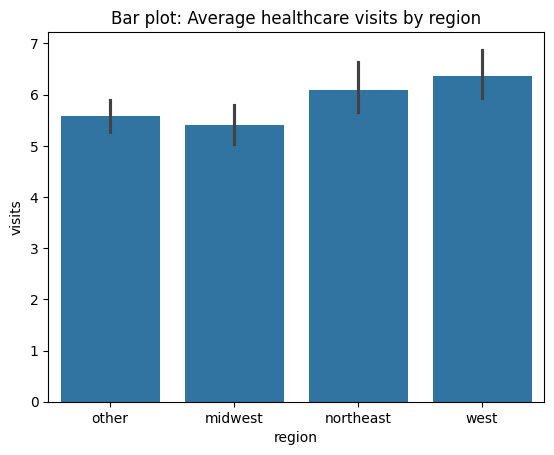

In [ ]:
# Bar plot for healthcare visits by Region
sns.barplot(x='region', y='visits', data=df)
plt.title('Bar plot: Average healthcare visits by region')
plt.show()

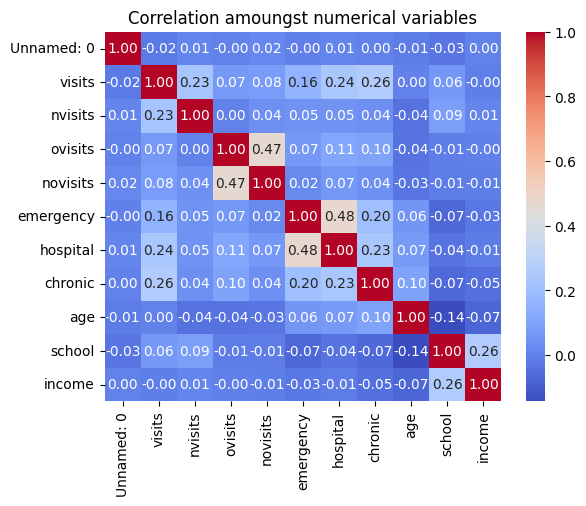

In [ ]:
# Heatmap showing correlation among numerical variables
correlation_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation amoungst numerical variables')
plt.show()

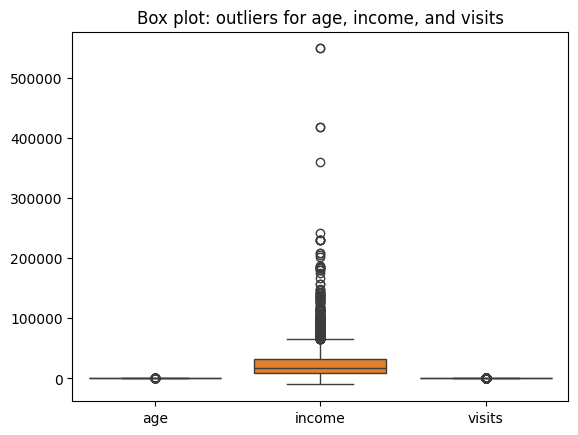

In [ ]:
# Box plot to identify outliers in Age, Income, and Visits
sns.boxplot(data=df[['age','income', 'visits']])
plt.title('Box plot: outliers for age, income, and visits')
plt.show()

Record observations and insights from visualizations:
After reviewing all the visualizations, the heatmap indicates that healthcare visits are strongly associated with hospital stays, chronic conditions, and emergency occurrences. Additionally, most visits were concentrated among patients living in the West region, and a large portion of these visits were linked to individuals reporting poor health..